# **Data Preprocessing**

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

Data Loading

In [2]:
df = pd.read_excel('premiums_rest.xlsx')

In [3]:
df.shape

(29904, 13)

In [4]:
df.head(5)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610


In [102]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.593480,1.712080,23.018200,15768.116320
std,15.000437,1.498248,24.219197,8419.839675
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13929.000000
75%,45.000000,3.000000,31.000000,22275.250000
max,356.000000,5.000000,930.000000,43471.000000


In [5]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [6]:
df.columns = df.columns.str.replace(" ","_").str.lower()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29904 entries, 0 to 29903
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    29904 non-null  int64 
 1   gender                 29904 non-null  object
 2   region                 29904 non-null  object
 3   marital_status         29904 non-null  object
 4   number_of_dependants   29904 non-null  int64 
 5   bmi_category           29904 non-null  object
 6   smoking_status         29895 non-null  object
 7   employment_status      29903 non-null  object
 8   income_level           29895 non-null  object
 9   income_lakhs           29904 non-null  int64 
 10  medical_history        29904 non-null  object
 11  insurance_plan         29904 non-null  object
 12  annual_premium_amount  29904 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 3.0+ MB


In [8]:
df.isna().mean()*100

age                      0.000000
gender                   0.000000
region                   0.000000
marital_status           0.000000
number_of_dependants     0.000000
bmi_category             0.000000
smoking_status           0.030096
employment_status        0.003344
income_level             0.030096
income_lakhs             0.000000
medical_history          0.000000
insurance_plan           0.000000
annual_premium_amount    0.000000
dtype: float64

In [9]:
df['income_level'].unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L', nan], dtype=object)

In [10]:
df[df['income_level'].isna()]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
4262,33,Male,Southeast,Married,2,Normal,Regular,Self-Employed,NaN,7,High blood pressure,Silver,18335
9155,27,Female,Northeast,Unmarried,2,Underweight,No Smoking,Freelancer,NaN,5,No Disease,Silver,14469
9198,52,Male,Northeast,Married,3,Underweight,No Smoking,Freelancer,NaN,8,Thyroid,Silver,19535
10391,40,Female,Northeast,Married,4,Obesity,Regular,Self-Employed,NaN,8,High blood pressure,Silver,22392
13435,37,Female,Southeast,Unmarried,0,Underweight,Regular,Salaried,NaN,7,High blood pressure,Silver,18631
18166,39,Female,Southeast,Unmarried,2,Obesity,No Smoking,NaN,NaN,8,High blood pressure,Silver,20114
26461,40,Male,Southwest,Unmarried,0,Underweight,Occasional,Salaried,NaN,6,High blood pressure,Silver,16663
26978,28,Female,Southwest,Married,3,Normal,No Smoking,Salaried,NaN,7,No Disease,Silver,13901
28490,54,Male,Southwest,Married,4,Normal,Occasional,Self-Employed,NaN,2,Diabetes,Silver,19531


In [11]:
df['employment_status'].unique()

array(['Salaried', 'Self-Employed', 'Freelancer', nan], dtype=object)

In [12]:
df['medical_history'].unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

In [13]:
df[df['smoking_status'].isna()]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
115,26,Female,Southwest,Married,3,Underweight,NaN,Salaried,> 40L,69,Diabetes,Gold,22605
9313,47,Male,Southwest,Married,4,Normal,NaN,Freelancer,25L - 40L,32,Diabetes,Gold,26100
9728,45,Male,Northwest,Married,4,Overweight,NaN,Salaried,10L - 25L,16,High blood pressure & Heart disease,Silver,21881
10096,34,Male,Southwest,Married,5,Normal,NaN,Self-Employed,25L - 40L,35,High blood pressure & Heart disease,Gold,25865
10736,61,Female,Southwest,Married,2,Normal,NaN,Self-Employed,25L - 40L,27,Thyroid,Gold,32501
12122,50,Female,Northeast,Married,3,Underweight,NaN,Salaried,25L - 40L,25,High blood pressure,Gold,27317
13604,69,Male,Southeast,Married,2,Normal,NaN,Freelancer,<10L,9,Diabetes,Silver,23118
15223,54,Male,Southwest,Married,3,Overweight,NaN,Salaried,> 40L,54,High blood pressure & Heart disease,Silver,24907
16286,58,Female,Southwest,Married,3,Obesity,NaN,Self-Employed,25L - 40L,32,Diabetes,Gold,30112


In [14]:
df[(df['medical_history'] == 'High blood pressure & Heart disease') & (df['bmi_category'] == 'Overweight')]['smoking_status'].mode()

0    Regular
Name: smoking_status, dtype: object

In [15]:
smoking_mode = (
    df.groupby(['medical_history', 'bmi_category'])['smoking_status']
    .agg(lambda x: pd.Series.mode(x)[0] if not pd.Series.mode(x).empty else None)
    .reset_index()
)

print(smoking_mode)

                        medical_history bmi_category smoking_status
0                              Diabetes       Normal     No Smoking
1                              Diabetes      Obesity     No Smoking
2                              Diabetes   Overweight        Regular
3                              Diabetes  Underweight     No Smoking
4              Diabetes & Heart disease       Normal     No Smoking
5              Diabetes & Heart disease      Obesity     No Smoking
6              Diabetes & Heart disease   Overweight        Regular
7              Diabetes & Heart disease  Underweight     No Smoking
8        Diabetes & High blood pressure       Normal     No Smoking
9        Diabetes & High blood pressure      Obesity     No Smoking
10       Diabetes & High blood pressure   Overweight        Regular
11       Diabetes & High blood pressure  Underweight     No Smoking
12                   Diabetes & Thyroid       Normal     No Smoking
13                   Diabetes & Thyroid      Obe

In [16]:
"""
Handling Missing Values:

- income_level:
  Missingness is likely dependent on the observed feature income_lakhs,
  as both represent income information. Hence, this is classified as MAR
  (Missing At Random). I impute income_level using income_lakhs.

- smoking_status:
  Missingness is likely related to the unobserved value itself, as individuals
  may choose not to disclose their smoking habits. Therefore, it is classified
  as MNAR (Missing Not At Random). Instead of naive imputation, I treat missing
  values as a separate category ('Unknown') and optionally create a missing indicator.

- employment_status:
  Missingness does not appear to depend on the value itself but may depend on
  other observed features such as income_level. Hence, it is treated as MAR.
  I impute missing values using conditional mode imputation based on income_level.
"""


"\nHandling Missing Values:\n\n- income_level:\n  Missingness is likely dependent on the observed feature income_lakhs,\n  as both represent income information. Hence, this is classified as MAR\n  (Missing At Random). I impute income_level using income_lakhs.\n\n- smoking_status:\n  Missingness is likely related to the unobserved value itself, as individuals\n  may choose not to disclose their smoking habits. Therefore, it is classified\n  as MNAR (Missing Not At Random). Instead of naive imputation, I treat missing\n  values as a separate category ('Unknown') and optionally create a missing indicator.\n\n- employment_status:\n  Missingness does not appear to depend on the value itself but may depend on\n  other observed features such as income_level. Hence, it is treated as MAR.\n  I impute missing values using conditional mode imputation based on income_level.\n"

In [17]:
def map_income_level(x):
    if pd.isna(x):
        return None
    elif x < 10:
        return '<10L'
    elif 10 <= x < 25:
        return '10L - 25L'
    elif 25 <= x < 40:
        return '25L - 40L'
    else:
        return '> 40L'

In [18]:
mask = df['income_level'].isna()
df.loc[mask, 'income_level'] = df.loc[mask, 'income_lakhs'].apply(map_income_level)

In [19]:
df['smoking_status'] = df['smoking_status'].fillna('Unknown')

In [20]:
global_mode = df['employment_status'].mode()[0]

def fill_mode_safe(series):
    mode = series.mode()
    return series.fillna(mode[0] if not mode.empty else global_mode)

df['employment_status'] = (
    df.groupby('income_level')['employment_status']
      .transform(fill_mode_safe)
)

In [21]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,29904.000000,29904.000000,29904.000000,29904.000000
mean,43.396536,2.380116,23.362059,20893.036684
std,13.411893,1.431140,24.737076,6935.844219
min,26.000000,-3.000000,1.000000,3625.000000
25%,34.000000,1.000000,7.000000,15698.000000
50%,42.000000,3.000000,17.000000,20489.000000
75%,52.000000,3.000000,32.000000,26360.000000
max,356.000000,5.000000,930.000000,43471.000000


In [24]:
df['number_of_dependants'].value_counts()/len(df)*100

number_of_dependants
3    31.828518
2    20.706260
4    15.807250
0    15.295613
1    10.831327
5     5.531033
Name: count, dtype: float64

In [23]:
df['number_of_dependants'] = df['number_of_dependants'].abs()

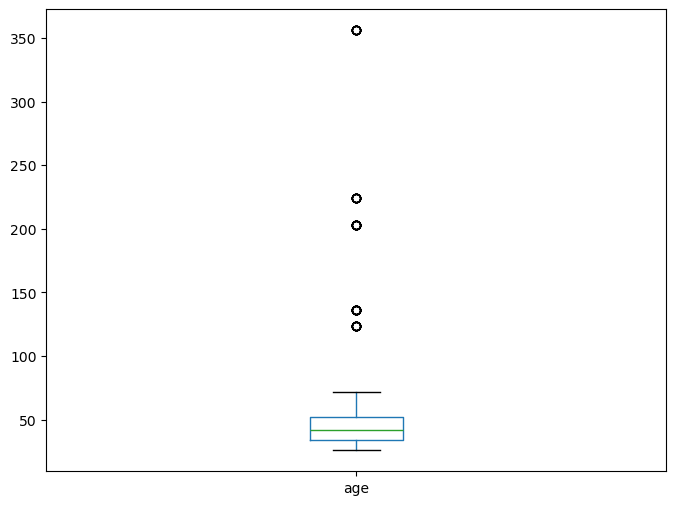

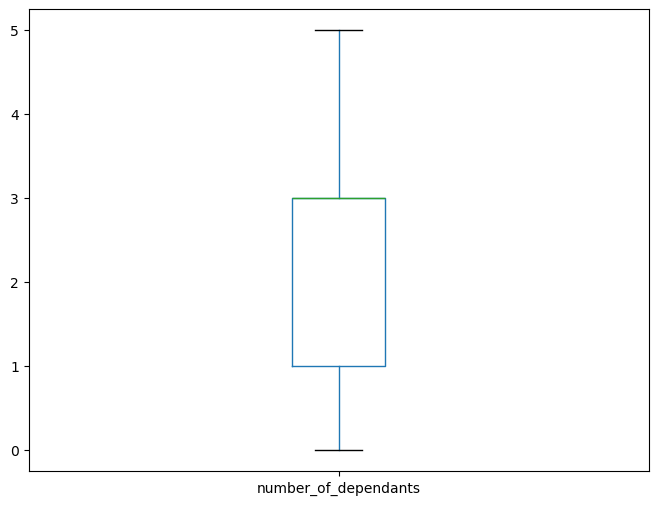

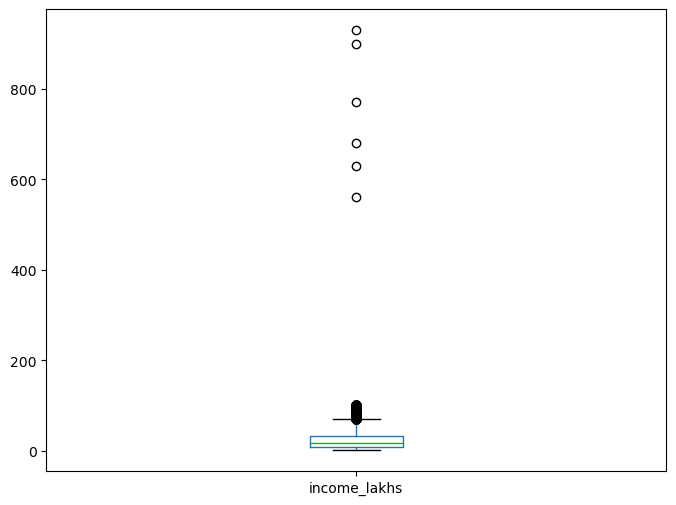

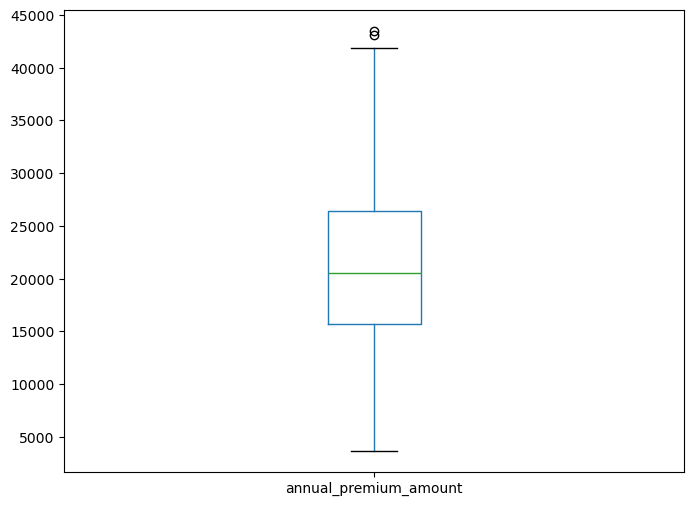

In [25]:
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_columns:
  df.boxplot(column=col, grid=False, figsize=(8, 6))
  plt.show()

In [26]:
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] >= lower) & (df[col] <= upper)]

df = remove_outliers_iqr(df, 'age')

In [27]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,29846.000000,29846.000000,29846.000000,29846.000000
mean,43.095993,2.387992,23.369396,20902.629063
std,11.042658,1.420585,24.747987,6927.489391
min,26.000000,0.000000,1.000000,6538.000000
25%,34.000000,1.000000,7.000000,15707.000000
50%,42.000000,3.000000,17.000000,20496.500000
75%,52.000000,3.000000,32.000000,26360.000000
max,72.000000,5.000000,930.000000,43471.000000


In [28]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
  print(f"{col}:{df[col].unique()}")

gender:['Male' 'Female']
region:['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status:['Unmarried' 'Married']
bmi_category:['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status:['No Smoking' 'Regular' 'Occasional' 'Unknown' 'Does Not Smoke'
 'Not Smoking' 'Smoking=0']
employment_status:['Salaried' 'Self-Employed' 'Freelancer']
income_level:['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history:['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan:['Bronze' 'Silver' 'Gold']


In [29]:
df.duplicated().sum()

0

In [30]:
df['smoking_status'] = df['smoking_status'].replace({
    'Not Smoking': 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Smoking=0': 'No Smoking'
})

df['smoking_status'].unique()

array(['No Smoking', 'Regular', 'Occasional', 'Unknown'], dtype=object)

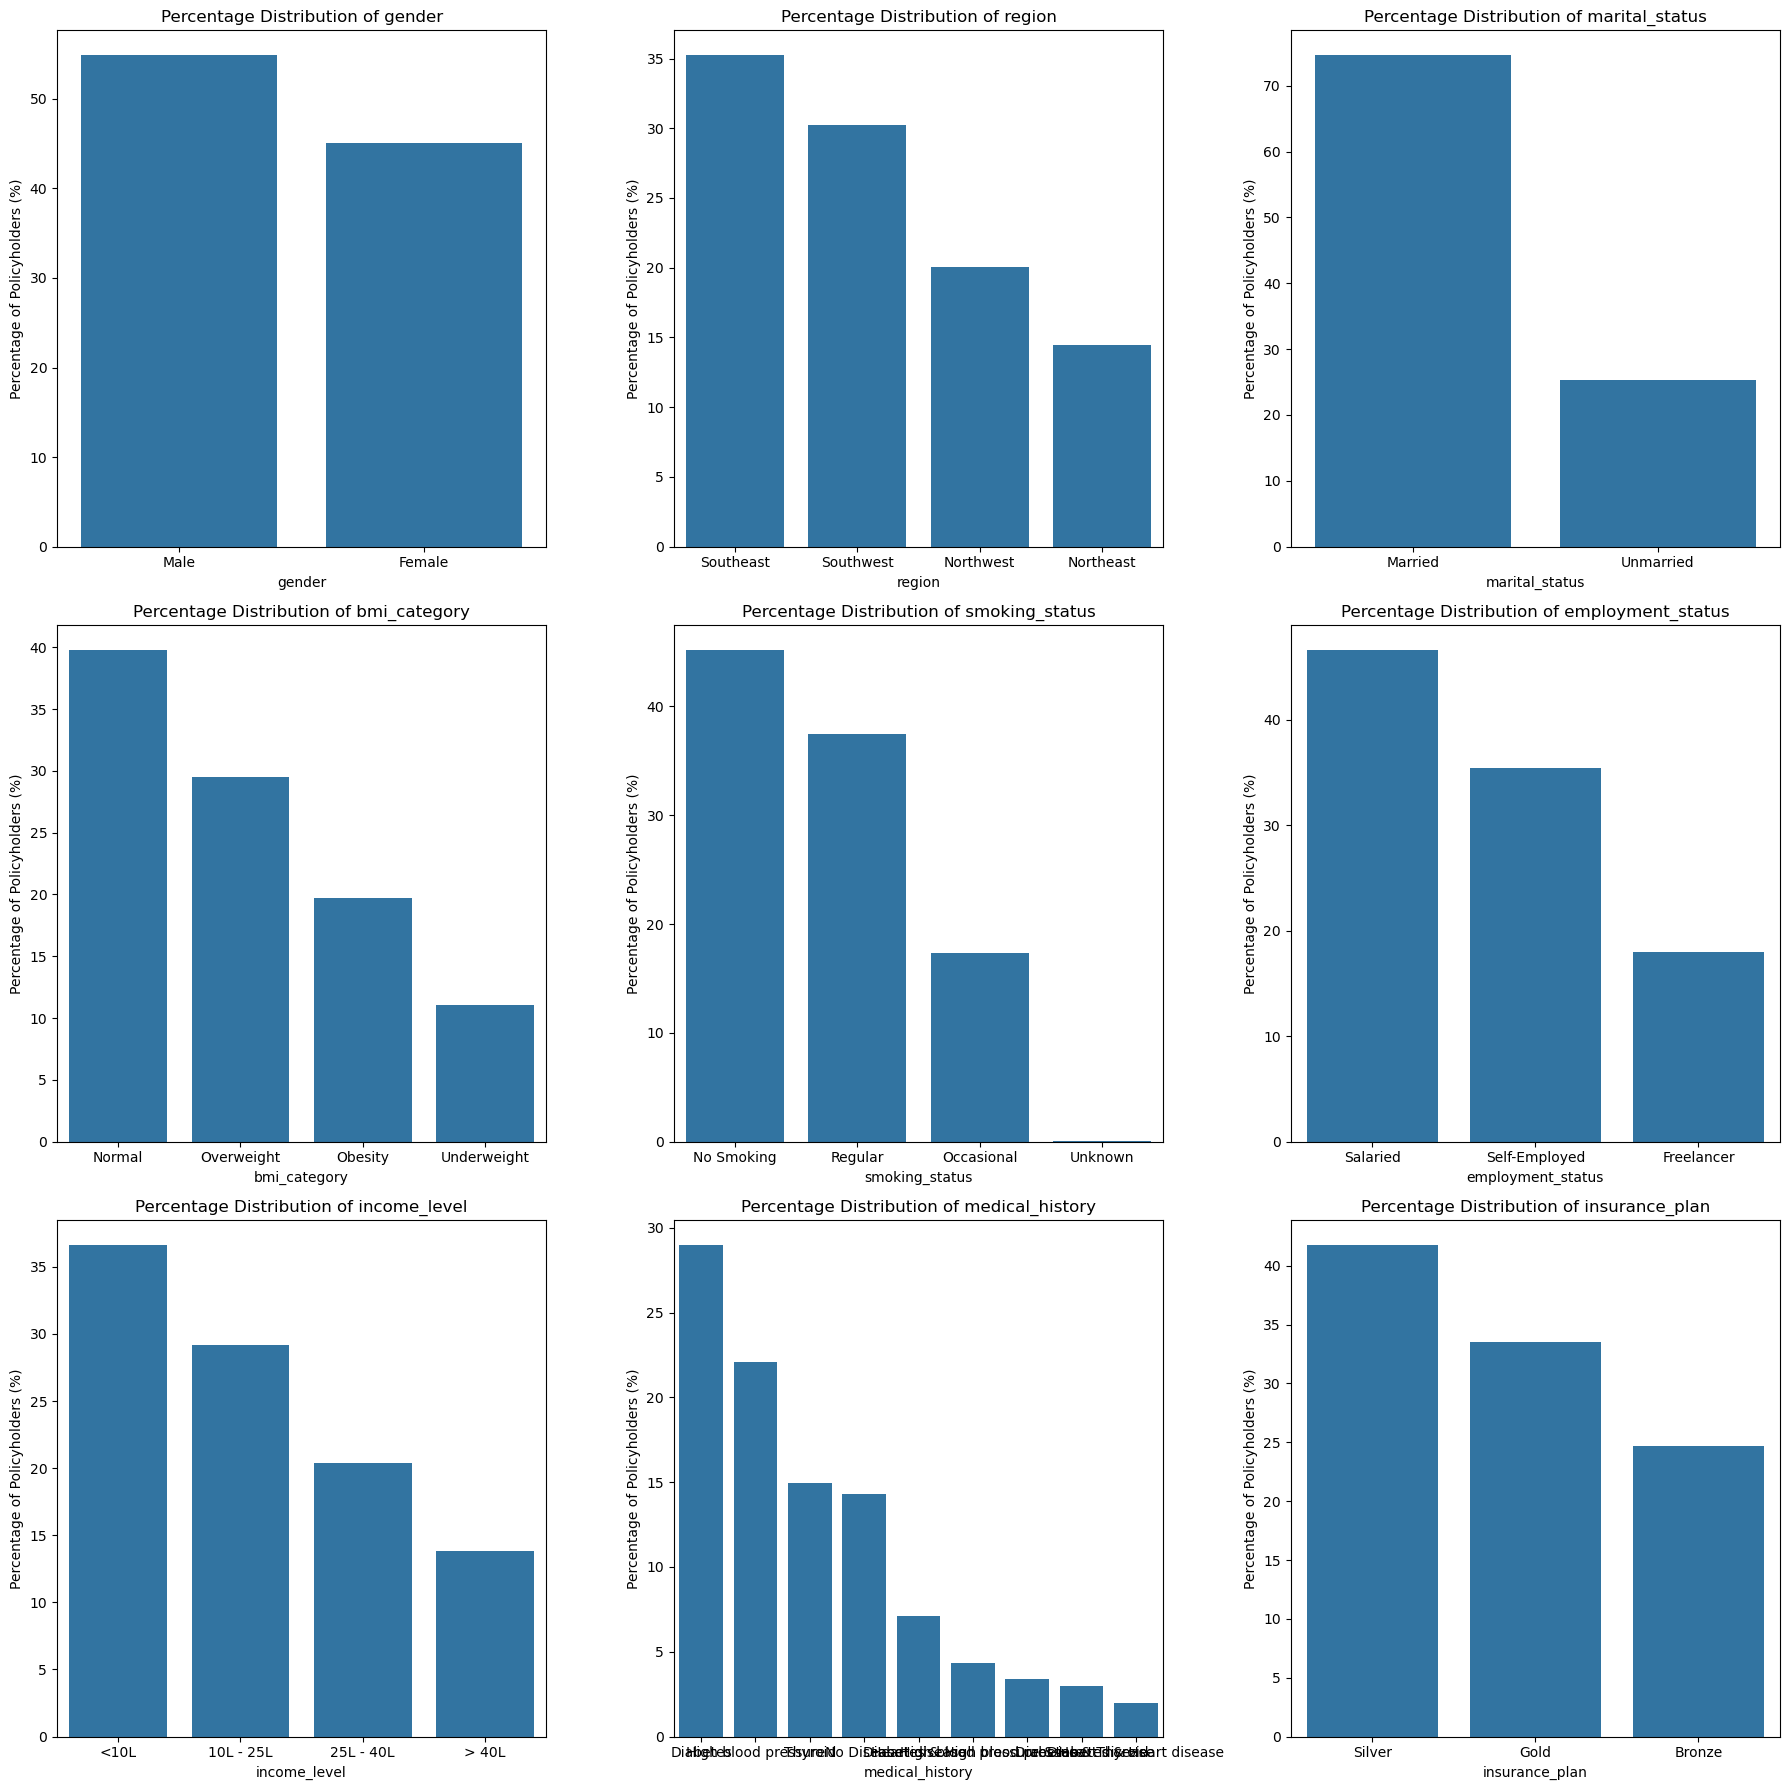

In [31]:
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(18, 18))  # Adjust figure size as necessary
axes = axes.flatten()  # Flatten the 2D array of axes into 1D for easier iteration

for ax, column in zip(axes, categorical_cols):
    # Calculate the percentage distribution of each category
    category_counts = df[column].value_counts(normalize=True) * 100  # normalize=True gives the relative frequencies

    # Plotting the distribution using barplot
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    ax.set_title(f'Percentage Distribution of {column}')
    ax.set_ylabel('Percentage of Policyholders (%)')
    ax.set_xlabel(column)  # Set xlabel to the column name for clarity

plt.tight_layout()  # Adjusts plot parameters for better fit in the figure window
plt.show()

In [32]:
crosstab = pd.crosstab(df['income_level'], df['insurance_plan'])
print(crosstab)

insurance_plan  Bronze  Gold  Silver
income_level                        
10L - 25L          799  3554    4355
25L - 40L          301  2636    3142
<10L              6054   527    4351
> 40L              214  3293     620


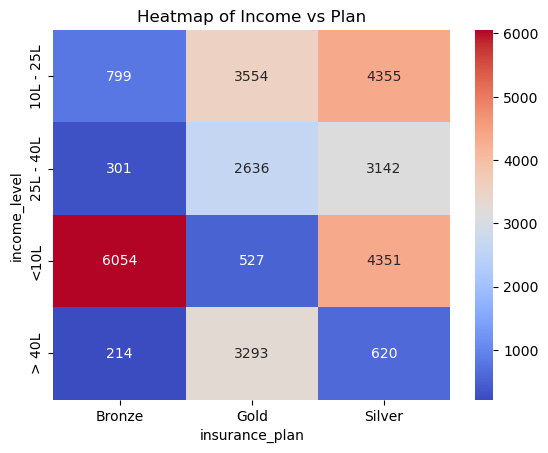

In [33]:
sns.heatmap(crosstab, annot=True, cmap='coolwarm',fmt="d")
plt.title('Heatmap of Income vs Plan')
plt.show()

In [34]:
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

df[['disease1', 'disease2']] = df['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())
df['disease1'] = df['disease1'].fillna('none')
df['disease2'] = df['disease2'].fillna('none')
df['total_risk_score'] = 0

for disease in ['disease1', 'disease2']:
    df['total_risk_score'] += df[disease].map(risk_scores)

# Normalize the risk score to a range of 0 to 1
max_score = df['total_risk_score'].max()
min_score = df['total_risk_score'].min()
df['normalized_risk_score'] = (df['total_risk_score'] - min_score) / (max_score - min_score)
df.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,none,6,0.428571


In [35]:
df['insurance_plan'] = df['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})

In [36]:
df['income_level'] = df['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})

In [37]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)
df.head(3)

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,...,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,smoking_status_Unknown,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,diabetes,none,6,...,0,1,0,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,diabetes,none,6,...,0,0,1,0,0,0,1,0,1,0
2,49,2,2,20,High blood pressure,2,18164,high blood pressure,none,6,...,0,0,0,0,0,0,0,0,0,1


In [38]:
df = df.drop(['medical_history','disease1', 'disease2', 'total_risk_score'], axis=1)
df.head(3)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,smoking_status_Unknown,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,0,1,0
2,49,2,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,0,1


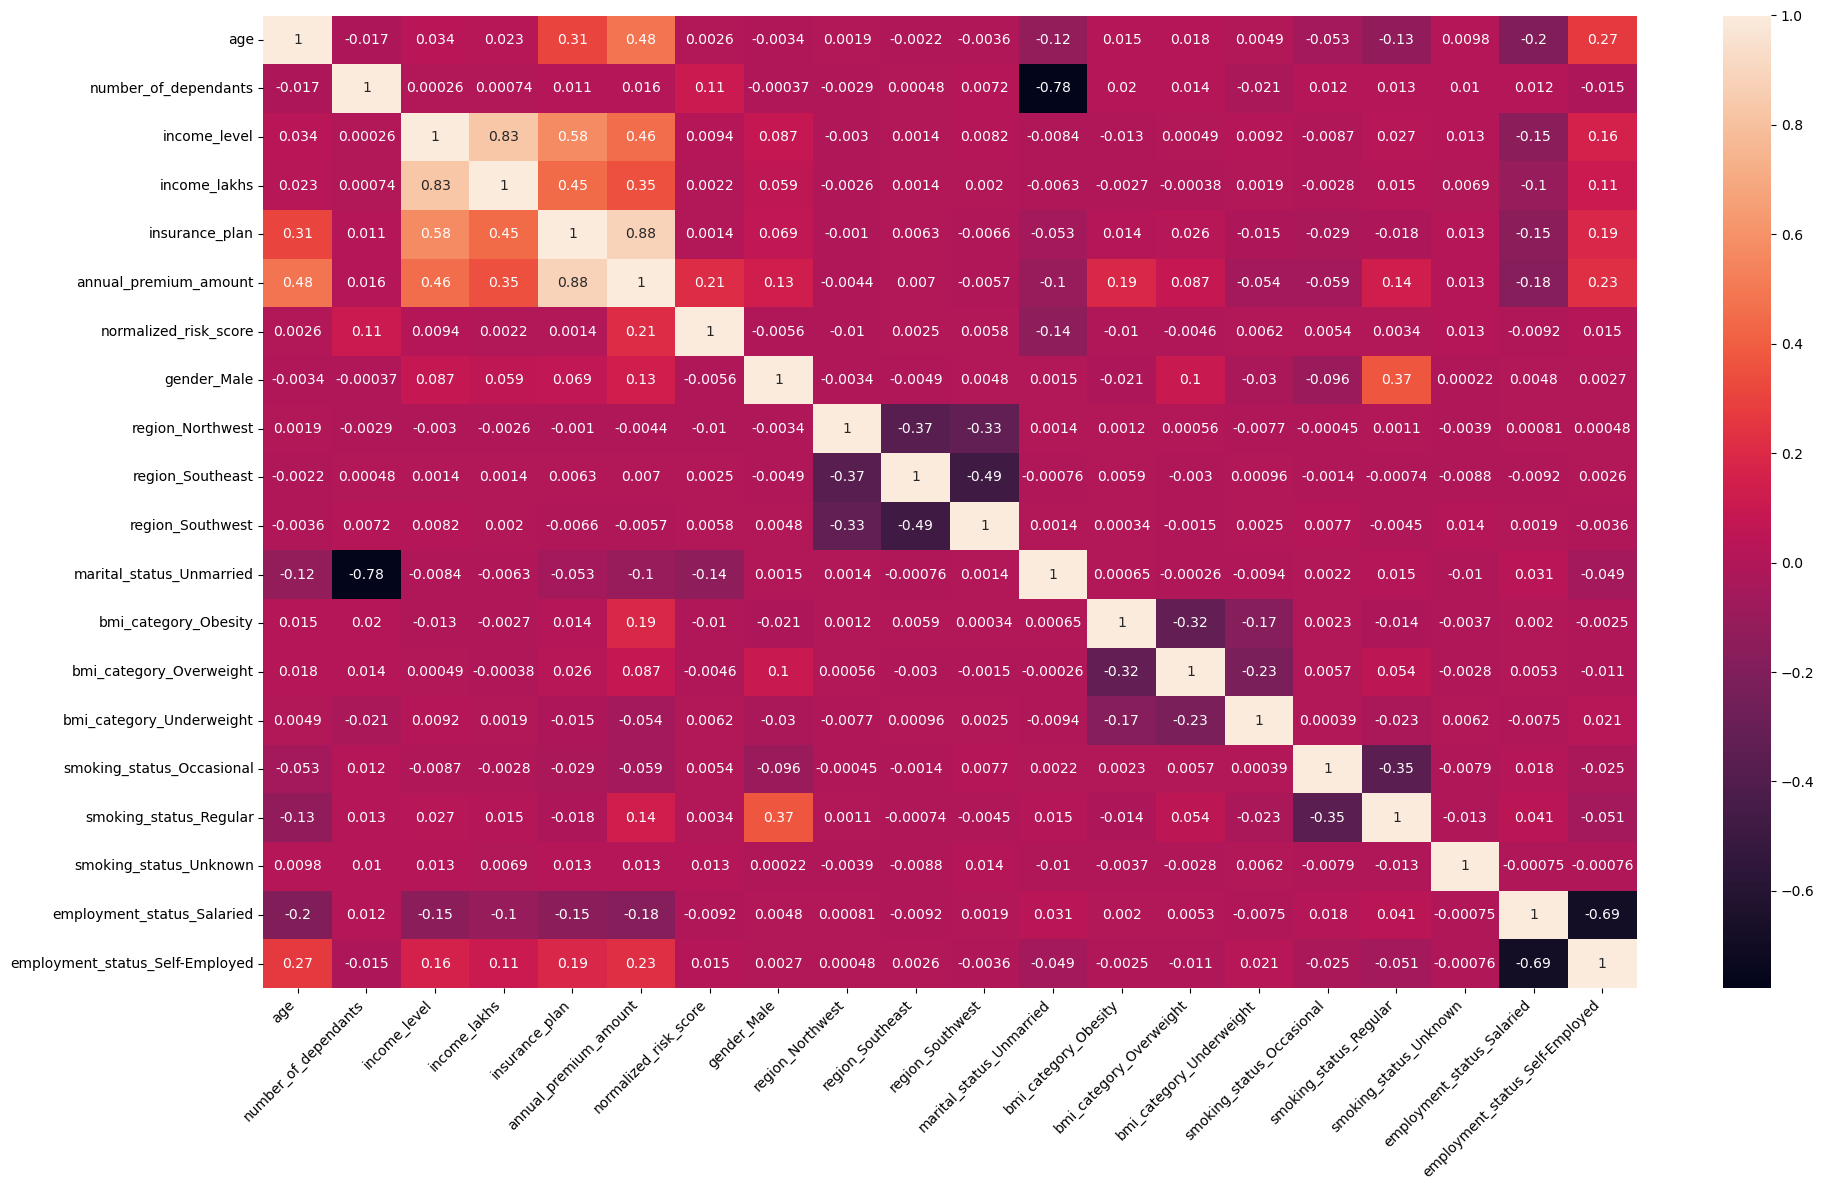

In [39]:
cm = df.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
X = df.drop('annual_premium_amount', axis='columns')
y = df['annual_premium_amount']

from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['age','number_of_dependants', 'income_level',  'income_lakhs', 'insurance_plan']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,smoking_status_Unknown,employment_status_Salaried,employment_status_Self-Employed
count,29846.000000,29846.000000,29846.000000,29846.000000,29846.000000,29846.000000,29846.000000,29846.000000,29846.000000,29846.000000,29846.000000,29846.000000,29846.000000,29846.000000,29846.000000,29846.000000,29846.000000,29846.000000,29846.000000
mean,0.371652,0.477598,0.371317,0.024079,0.544261,0.426394,0.549119,0.200630,0.352610,0.302051,0.253300,0.196911,0.294914,0.110199,0.173189,0.374489,0.000302,0.466126,0.354252
std,0.240058,0.284117,0.351207,0.026639,0.378959,0.240104,0.497590,0.400478,0.477791,0.459155,0.434909,0.397671,0.456012,0.313143,0.378417,0.483999,0.017363,0.498860,0.478294
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.173913,0.200000,0.000000,0.006459,0.500000,0.357143,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.347826,0.600000,0.333333,0.017223,0.500000,0.428571,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.565217,0.600000,0.666667,0.033369,1.000000,0.428571,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [41]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [42]:
calculate_vif(X)

,Column,VIF
0,age,3.919228
1,number_of_dependants,6.275631
2,income_level,8.502793
3,income_lakhs,5.948744
4,insurance_plan,5.256121
5,normalized_risk_score,3.811930
6,gender_Male,2.597394
7,region_Northwest,2.123282
8,region_Southeast,2.979215
9,region_Southwest,2.709887


In [43]:
calculate_vif(X.drop('income_level', axis="columns"))

,Column,VIF
0,age,3.847054
1,number_of_dependants,6.271351
2,income_lakhs,2.326801
3,insurance_plan,4.333418
4,normalized_risk_score,3.808895
5,gender_Male,2.590568
6,region_Northwest,2.122013
7,region_Southeast,2.977134
8,region_Southwest,2.706516
9,marital_status_Unmarried,2.342309


In [44]:
# # we will drop income_lakhs due to high VIF value
# X_reduced = X.drop('income_level', axis="columns")

<h2 align="center" style="color:blue">Model Training</h2>

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=10)

# shape of the X_train, X_test, y_train, y_test features
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (20892, 19)
x test:  (8954, 19)
y train:  (20892,)
y test:  (8954,)


In [46]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
test_score = model_lr.score(X_test, y_test)
train_score = model_lr.score(X_train, y_train)
train_score, test_score

(0.9537545598790524, 0.9532277772769381)

In [47]:
y_pred = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Linear Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Linear Regression ==> MSE:  2223729.6356374407 RMSE:  1491.2175011169365


In [48]:
X_test.shape

(8954, 19)

In [49]:
np.set_printoptions(suppress=True, precision=6)
model_lr.coef_

array([ 6976.963969, -1285.914043,  -494.14698 , -1222.477088,
       14930.091014,  6002.50273 ,    61.143184,   -36.058854,
          -9.614945,   -19.545737,  -691.209206,  3916.326266,
        1970.863222,   590.641676,   828.846293,  2792.469397,
         775.046588,   -79.68608 ,   229.302724])

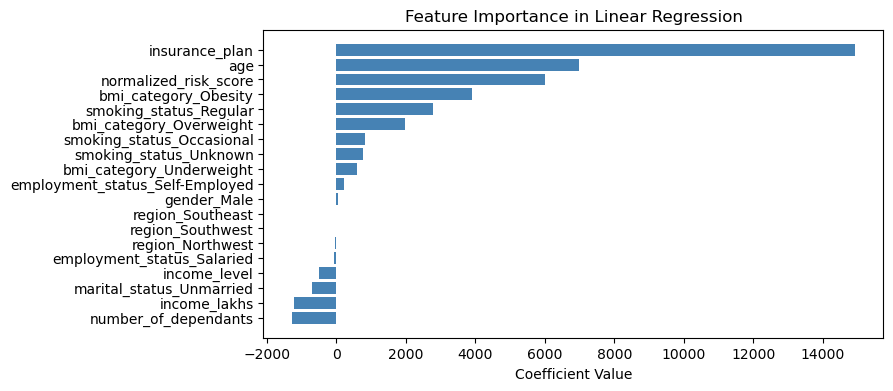

In [50]:
feature_importance = model_lr.coef_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

In [51]:
# Ridge Regression Model
model_rg = Ridge(alpha=1)
model_rg.fit(X_train, y_train)
test_score = model_rg.score(X_test, y_test)
train_score = model_rg.score(X_train, y_train)
train_score, test_score

(0.9537541522013236, 0.9532266260278071)

In [52]:
y_pred = model_rg.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Ridge Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Ridge Regression ==> MSE:  2223784.3704065355 RMSE:  1491.2358533801873


In [53]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=20, max_depth=3)
model_xgb.fit(X_train, y_train)
model_xgb.score(X_test, y_test)

0.9935792307303402

In [54]:
y_pred = model_xgb.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("XGBoost Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

XGBoost Regression ==> MSE:  305267.82943528215 RMSE:  552.5104790275766


In [55]:
model_xgb = XGBRegressor()
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}
random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=None)
random_search.fit(X_train, y_train)
random_search.best_score_

0.9969866446741356

In [56]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}

In [57]:
best_model = random_search.best_estimator_

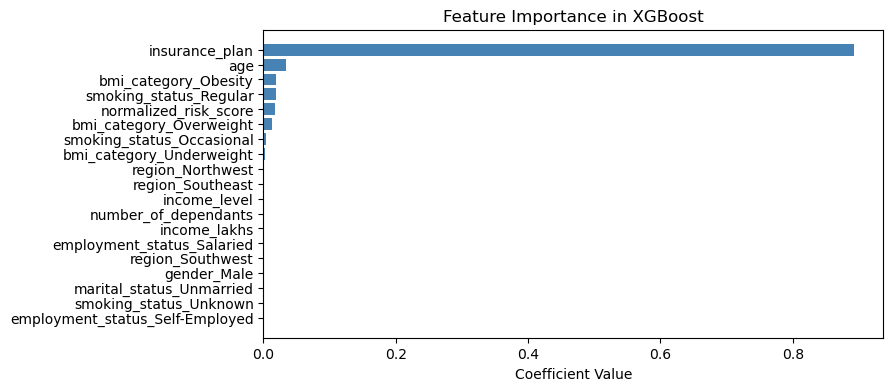

In [58]:
feature_importance = best_model.feature_importances_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in XGBoost')
plt.show()

In [59]:
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals / y_test) * 100

results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'diff': residuals,
    'diff_pct': residuals_pct
})
results_df.head()

,actual,predicted,diff,diff_pct
24685,31624,31375.072266,-248.927734,-0.787148
7548,22385,22558.871094,173.871094,0.776730
14698,18208,18936.068359,728.068359,3.998618
25288,11190,11229.176758,39.176758,0.350105
22874,15533,15898.896484,365.896484,2.355607


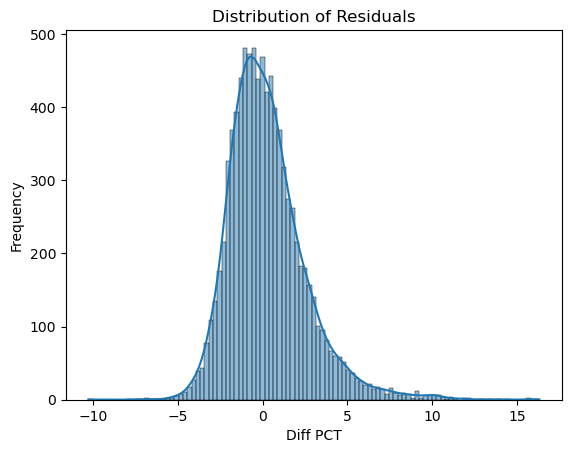

In [60]:
sns.histplot(results_df['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

In [61]:
extreme_error_threshold = 10  # You can adjust this threshold based on your domain knowledge or requirements
extreme_results_df = results_df[np.abs(results_df['diff_pct']) > extreme_error_threshold]
extreme_results_df.head()

,actual,predicted,diff,diff_pct
11189,8563,9447.992188,884.992188,10.335072
1549,8543,9447.992188,904.992188,10.593377
12189,6571,7605.027344,1034.027344,15.736225
28595,7580,8427.613281,847.613281,11.182233
12499,6801,7605.027344,804.027344,11.822193


In [66]:
extreme_results_df.shape

(35, 4)

In [62]:
extreme_errors_pct = extreme_results_df.shape[0]*100/X_test.shape[0]
extreme_errors_pct

0.39088675452311816

We have very few extreme errors (only 0.3%) which means this model looks good and no further investigation is required